<a href="https://colab.research.google.com/github/Alilson2/Projeto_IA/blob/main/Projeto_IA_Arima_regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr # Ler arquivos netcdf
from google.colab import drive
import seaborn as sns


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import matplotlib.patches as mpatches # Desenhar geometria em um mapa

In [9]:
import os
import xarray as xr

# --- Clonar repositório se não existir ---
if not os.path.exists("Projeto_IA"):
    !git clone https://github.com/Alilson2/Projeto_IA.git
else:
    print("📁 Repositório 'Projeto_IA' já existe — pulando o clone.")

# --- Verificar se a pasta foi criada ---
if not os.path.exists("Projeto_IA"):
    raise FileNotFoundError("❌ A pasta 'Projeto_IA' não foi encontrada. O clone pode ter falhado.")
else:
    print("\n✅ Repositório clonado com sucesso!\n")
    print("Arquivos dentro da pasta Projeto_IA:\n", os.listdir("Projeto_IA"))

# --- Localizar arquivos .nc ---
arquivos_nc = [f for f in os.listdir("Projeto_IA") if f.endswith(".nc")]
if not arquivos_nc:
    raise FileNotFoundError("❌ Nenhum arquivo .nc encontrado na pasta Projeto_IA!")
else:
    print("\n📂 Arquivo(s) NetCDF encontrado(s):")
    #for f in arquivos_nc:
        #print(" -", f)

# --- Montar lista de caminhos ---
ARQUIVO = [os.path.join("Projeto_IA", f) for f in arquivos_nc]

# --- Função para corrigir longitude ---
def corrigir_longitude(ds):
    for coord in ["longitude", "lon"]:
        if coord in ds.coords:
            ds = ds.assign_coords({coord: ((ds[coord] + 180) % 360) - 180})
            ds = ds.sortby(coord)
    return ds

# --- Abrir arquivos com segurança (nova sintaxe) ---
try:
    dados = xr.open_mfdataset(
        ARQUIVO,
        combine='by_coords',
        parallel=True,           # usa múltiplos núcleos
        preprocess=corrigir_longitude,
        combine_attrs='override' # 🟢 substitui o antigo compat='override'
    )
except ValueError as e:
    print("\n⚠️ Erro na combinação — tentando modo 'nested' (concat por tempo)...")
    dados = xr.open_mfdataset(
        ARQUIVO,
        combine='nested',
        concat_dim='valid_time',  # ajuste se sua dimensão temporal tiver outro nome
        parallel=True,
        preprocess=corrigir_longitude,
        combine_attrs='override'
    )

print("\n✅ Dataset carregado com sucesso!\n")

📁 Repositório 'Projeto_IA' já existe — pulando o clone.

✅ Repositório clonado com sucesso!

Arquivos dentro da pasta Projeto_IA:
 ['(JAN 2024 - 16a31) ea884d573d8753c6f2976f9e4b642c11.nc', '(ABR 2020-1 a 24).nc', '(OUT 2020-1 a 24).nc', '(SET 2020-1 a 24).nc', 'Projeto_IA_Arima_regressao.ipynb', '(DEZEMBRO 2024 - 16a31) 39b3910eee1ef3c1aaa6ca43cba3f9a5.nc', 'SET 2022 - 16a30.nc', '(Junho 2021-16 a 30).nc', '(SET 2020-25 a 30).nc', '(MAIO 2023 - 16a31) c5f19b02b4981b080ef04ca83a2585da.nc', '(JUN 2020-1 a 24).nc', 'AGO 2022 - 16a31.nc', '(DEZEMBRO 2023 - 1a15).nc', '(OUTUBRO 2024 - 16a31) b3f505f9374108f770a431d1f104a163.nc', '(MAIO 2021-16 a 30).nc', '(SETEMBRO 2023 - 16a30).nc', '(DEZEMBRO 2023 - 16a31).nc', '(MAIO 2024 - 1a15) 43295239c76e33d0ac9a1fdb69ad8f44.nc', 'OUT 2022 - 16a31.nc', '(FEV 2024 - 16a29) 3c44a136f94118edef61d5f38d0d27cd.nc', '(Julho 2021-16 a 31).nc', '(MAIO 2021-1 a 15).nc', '(AGOSTO 2021-16 a 31).nc', '(AGO 2020-1 a 24).nc', '(MARÇO 2023 - 1a15) ef5ac9bd28416b585

/tmp/ipython-input-3327130302.py:39: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(
/tmp/ipython-input-3327130302.py:39: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(



⚠️ Erro na combinação — tentando modo 'nested' (concat por tempo)...


/tmp/ipython-input-3327130302.py:48: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(
/tmp/ipython-input-3327130302.py:48: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(



✅ Dataset carregado com sucesso!



In [10]:
df = dados.to_dataframe()
df = df.dropna()

# --- 2️⃣ Verificar se há a coordenada temporal ---
if "valid_time" not in dados.coords:
    raise ValueError("❌ O dataset não contém uma coordenada temporal chamada 'valid_time'.")

# --- 3️⃣ Converter o eixo temporal para pandas.DatetimeIndex ---
tempo = pd.to_datetime(dados["valid_time"].values)

# --- 4️⃣ Criar DataFrame com componentes temporais ---
df_tempo = pd.DataFrame({
    "timestamp": tempo,
    "timestamp_segundos": tempo.view("int64"),   # segundos desde 1970
    "ano": tempo.year,
    "mes": tempo.month,
    "dia": tempo.day,
    "hora": tempo.hour,
    "minuto": tempo.minute,
    "segundo": tempo.second,
    "dia_semana": tempo.dayofweek,
    "dia_do_ano": tempo.dayofyear
})

#print(df_tempo.head())

# Exemplo: seleciona uma variável e um período
# Sort the dataset by valid_time before slicing
dados_sorted = dados.sortby('valid_time')
dados_filtrado = dados_sorted

# Converte para pandas sem estourar RAM
df_panda = dados_filtrado.to_dataframe().reset_index()
df_panda = df_panda.dropna()

# Junta com df_tempo
df_final = pd.merge(
    df_panda,
    df_tempo,
    left_on='valid_time',
    right_on='timestamp',
    how='left'
)


df_final['longitude'] = np.round(df_final['longitude'], 1)
df_final['latitude'] = np.round(df_final['latitude'], 1)

In [11]:
def selecionar_coordenadas(df, N_lim, S_lim, L_lim, O_lim):

    df = df[
        (df["latitude"] <= N_lim) &
        (df["latitude"] >= S_lim) &
        (df["longitude"] >= O_lim) &
        (df["longitude"] <= L_lim)
    ]

    df = df.drop_duplicates(subset=["valid_time", "latitude", "longitude"])
    return df


def calcula_vapor_umidade(df):

    t2m_c = df["t2m"] - 273.15
    d2m_c = df["d2m"] - 273.15

    es = 610.94 * np.exp(17.625 * t2m_c / (243.04 + t2m_c))
    ev = 610.94 * np.exp(17.625 * d2m_c / (243.04 + d2m_c))

    df["es"]  = es
    df["ev"]  = ev
    df["RH"]  = 100 * ev / es
    df["VPD"] = (es - ev) / 1000

    return df


def criar_dados(df):

    df["data"] = pd.to_datetime(df["valid_time"]).dt.date

    # Variáveis com estatísticas: mean, min, max
    vars_stats = ['d2m', 't2m', 'u10', 'v10', 'sp', 'es', 'ev', 'RH', 'VPD']

    # Variáveis que usam somente o último valor do dia
    vars_last = ["e", "ssrd", "sshf", "slhf", "tp"]

    g = df.groupby(["data", "latitude", "longitude"])

    resultados = {}

    # ---------- Estatísticas ----------
    for var in vars_stats:
        resultados[f"{var}_mean"] = g[var].mean()
        resultados[f"{var}_min"]  = g[var].min()
        resultados[f"{var}_max"]  = g[var].max()

    # ---------- Último valor ----------
    for var in vars_last:
        resultados[f"{var}_last"] = g[var].last()

    df_pixel = pd.concat(resultados, axis=1).reset_index()
    return df_pixel


def agregar_regional(df_pixel):

    df_pixel["data"] = pd.to_datetime(df_pixel["data"])
    df_pixel["mes"]  = df_pixel["data"].dt.month

    g = df_pixel.groupby("data")
    resultados = {}

    for col in df_pixel.columns:
        if col in ["data", "latitude", "longitude", "mes"]:
            continue

        # Últimos valores → média espacial
        if col.endswith("_last"):
            var = col.replace("_last", "")
            resultados[f"{var}_mean"] = g[col].mean()
            continue

        # Estatísticas (mean/min/max por pixel por dia)
        if "_mean" in col:
            var = col.replace("_mean", "")
            resultados[f"{var}_mean"] = g[col].mean()
            resultados[f"{var}_std"]  = g[col].std()
            continue

        if "_min" in col:
            var = col.replace("_min", "")
            resultados[f"{var}_min"]  = g[col].min()
            continue

        if "_max" in col:
            var = col.replace("_max", "")
            resultados[f"{var}_max"]  = g[col].max()
            continue

    df_regional = pd.concat(resultados, axis=1).reset_index()
    df_regional["mes"] = df_regional["data"].dt.month

    return df_regional


def pipeline(df_raw, N_lim, S_lim, L_lim, O_lim):

    df = selecionar_coordenadas(df_raw, N_lim, S_lim, L_lim, O_lim)
    df = calcula_vapor_umidade(df)
    df_daily_pixel = criar_dados(df)
    df_regional = agregar_regional(df_daily_pixel)

    return df_regional


def remover_correlacoes(X, threshold=0.90):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    print(f"\n[Remoção por correlação] Features removidas (>{threshold}): {len(to_drop)}")
    print(to_drop)

    return X.drop(columns=to_drop), to_drop


def diagnosticar_overfitting(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test, y_pred_test)
    diff = acc_train - acc_test

    cv_scores = cross_val_score(model, X_train, y_train, cv=10)
    cv_mean = cv_scores.mean()

    print("\n================ DIAGNÓSTICO DE OVERFITTING ================")
    print(f"Acurácia Treino: {acc_train:.4f}")
    print(f"Acurácia Teste:  {acc_test:.4f}")
    print(f"Diff Treino - Teste: {diff:.4f}")
    print("-------------------------------------------------------------")
    print(f"Cross-Validation (média 10 folds): {cv_mean:.4f}")
    print(f"Desvio CV: {cv_scores.std():.4f}")
    print("-------------------------------------------------------------")

    if diff < 0.05:
        status = "OK — Sem sinais de overfitting."
    elif diff < 0.10:
        status = "Atenção — Overfitting leve."
    elif diff < 0.20:
        status = "Overfitting moderado."
    else:
        status = "Overfitting severo — modelo está decorando os dados."

    print("Diagnóstico:", status)
    print("=============================================================\n")



def separar_dados(df_diario, limiar = 0.0005):
  X = df_diario.drop(['data', 'tp_mean'], axis=1)
  y = df_diario['tp_mean'].copy()

  ind_sem_chuva = np.where(y <= limiar)[0]
  ind_com_chuva = np.where(y > limiar)[0]

  y.iloc[ind_sem_chuva] = 0
  y.iloc[ind_com_chuva] = 1

  return X, y

def data_treino_teste(df_diario):
  ind_per = int(0.8 * len(df_diario))
  df_train = df_diario.iloc[:ind_per].copy()
  df_test  = df_diario.iloc[ind_per:].copy()

  df_train["tp_mean"] = df_train["tp_mean"].shift(-1)
  df_test["tp_mean"]  = df_test["tp_mean"].shift(-1)

  df_train = df_train.dropna().reset_index(drop=True)
  df_test  = df_test.dropna().reset_index(drop=True)
  return df_train, df_test

def selecionar_features(X_train, X_test, y_train, k=15):
  rf_temp = RandomForestClassifier(
      n_estimators=200,
      max_depth=8,
      random_state=42#,
      #class_weight='balanced_subsample'
  )

  rf_temp.fit(X_train, y_train)

  importances = pd.DataFrame({
      'feature': X_train.columns,
      'importance': rf_temp.feature_importances_
  }).sort_values('importance', ascending=False)

  print("\n[IMPORTÂNCIA DAS FEATURES]")
  print(importances.head(20))

  k = 15
  top_k_features = importances.head(k)["feature"].tolist()

  print(f"\nTop {k} features selecionadas:")
  print(top_k_features)

  X_train_sel = X_train[top_k_features]
  X_test_sel  = X_test[top_k_features]
  return X_train_sel, X_test_sel

In [12]:

O_lim = -46.84
L_lim = -46.36
N_lim = -23.4
S_lim = -23.74

df_panda = df_final
df_diario = pipeline(df_panda, N_lim, S_lim, L_lim, O_lim)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  

ARIMA Model Fit Summary (on training data):
                               SARIMAX Results                                
Dep. Variable:                tp_mean   No. Observations:                 1461
Model:                          ARIMA   Log Likelihood                5212.549
Date:                Fri, 05 Dec 2025   AIC                         -10421.097
Time:                        01:58:07   BIC                         -10410.523
Sample:                    01-01-2020   HQIC                        -10417.153
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0039      0.000     15.032      0.000       0.003       0.004
sigma2      4.656e-05   7.41e-07     62.854      0.000    4.51e-05     4.8e-05
Ljung-Bo

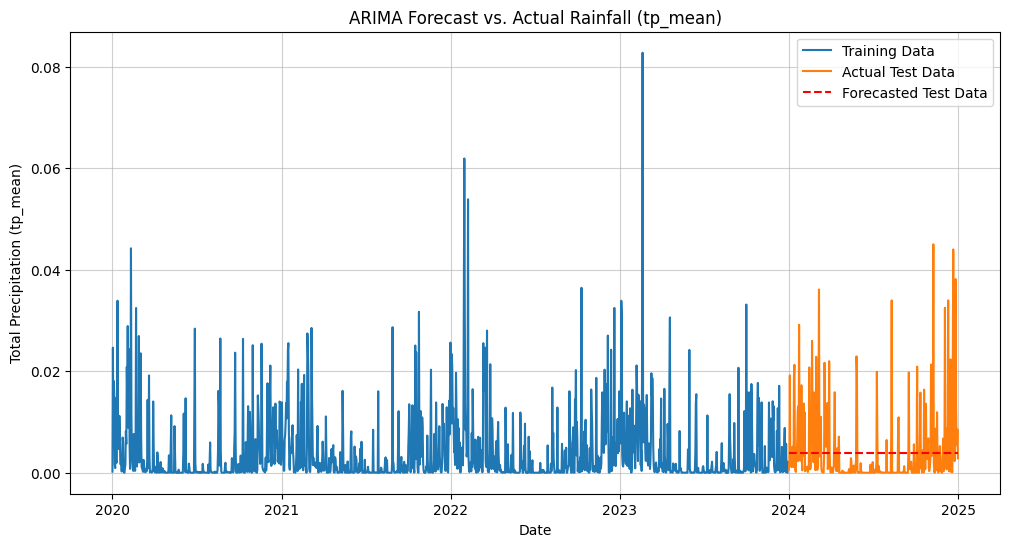

In [13]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = df_diario.copy()
df['data'] = pd.to_datetime(df['data'])
df = df.set_index('data')
df_ts = df['tp_mean']

split_idx = int(len(df_ts) * 0.8)
y_train = df_ts.iloc[:split_idx]
y_test = df_ts.iloc[split_idx:]

model_train = ARIMA(y_train)
model_fit = model_train.fit()
print(f"ARIMA Model Fit Summary (on training data):")
print(model_fit.summary())

y_pred = model_fit.forecast(steps=len(y_test))


mse = mean_squared_error(y_test, y_pred)
print(f"\nTest Mean Squared Error (MSE): {mse:.4f}")

final_model = ARIMA(df_ts)
final_model_fit = final_model.fit()

        # Forecast one step ahead (the day after the last date in the data)
next_day_forecast = final_model_fit.forecast(steps=1).iloc[0]
last_date = df_ts.index[-1].strftime('%Y-%m-%d')
next_date = (df_ts.index[-1] + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

print(f"Last date in data: {last_date}")
print(f"Forecast date: {next_date}")
print(f"Predicted Total Precipitation (tp_mean) on {next_date}: {next_day_forecast:.4f}")

        # Interpretation based on common sense (rain is generally non-negative)
if next_day_forecast < 0:

  next_day_forecast = max(0.0, next_day_forecast)

plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Training Data')
plt.plot(y_test.index, y_test, label='Actual Test Data')
plt.plot(y_test.index, y_pred, label='Forecasted Test Data', color='red', linestyle='--')
plt.title(f'ARIMA Forecast vs. Actual Rainfall (tp_mean)')
plt.xlabel('Date')
plt.ylabel('Total Precipitation (tp_mean)')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()

In [14]:
import pandas as pd
from statsmodels.formula.api import logit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("--- 1. Data Loading and Preparation ---")
df = df_diario.copy()

df['data'] = pd.to_datetime(df['data'])
df = df.set_index('data')

df['Rain_Today'] = (df['tp_mean'] > 0.0005).astype(int)

predictors = ['d2m_min', 'd2m_max', 't2m_min', 'u10_max', 'v10_min', 'sp_min', 'sp_max', 'es_mean', 'es_std', 'es_min', 'es_max', 'ev_mean', 'ev_std', 'ev_min', 'ev_max', 'VPD_mean', 'VPD_min', 'VPD_max', 'slhf_mean']

lag_columns = []
for col in predictors:
      lag_col_name = f'{col}_lag1'
      df[lag_col_name] = df[col].shift(1)
      lag_columns.append(lag_col_name)

df_clean = df.dropna(subset=lag_columns)

split_idx = int(len(df_clean) * 0.8)
train_data = df_clean.iloc[:split_idx]
test_data = df_clean.iloc[split_idx:]

formula = "Rain_Today ~ " + " + ".join(lag_columns)

print("\n--- 3. Model Fitting (Multivariable AR-Logit) ---")
print(f"Formula used: {formula}")

logit_model = logit(formula, data=train_data).fit(disp=0)
print("\nLogit Model Summary (on training data):")
print(logit_model.summary())


y_prob = logit_model.predict(test_data)

y_pred = (y_prob >= 0.5).astype(int)


y_actual = test_data['Rain_Today']


cm = confusion_matrix(y_actual, y_pred, labels=[0, 1])


accuracy = accuracy_score(y_actual, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")

print("\nConfusion Matrix:")
cm_df = pd.DataFrame(cm,
                      index=['Actual: No Rain (0)', 'Actual: Rain (1)'],
                      columns=['Predicted: No Rain (0)', 'Predicted: Rain (1)'])
print(cm_df)

print("\nClassification Report:")


print(classification_report(y_actual, y_pred,
                            target_names=['No Rain', 'Rain'],
                            labels=[0, 1],
                            zero_division=0))

print("\n--- 5. Next Day Prediction ---")


final_logit_model = logit(formula, data=df_clean).fit(disp=0)


last_day_features = df.tail(1)[predictors].rename(columns=lambda x: f'{x}_lag1')


next_day_prob = final_logit_model.predict(last_day_features).iloc[0]
next_day_prediction = 'RAIN' if next_day_prob >= 0.5 else 'NO RAIN'

last_date = df.index[-1].strftime('%Y-%m-%d')
next_date = (df.index[-1] + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

print(f"Weather conditions used (from {last_date}):")
print(last_day_features)
print(f"\nPredicted Probability of Rain on {next_date}: {next_day_prob:.4f}")
print(f"Final Prediction: {next_day_prediction}")

--- 1. Data Loading and Preparation ---

--- 3. Model Fitting (Multivariable AR-Logit) ---
Formula used: Rain_Today ~ d2m_min_lag1 + d2m_max_lag1 + t2m_min_lag1 + u10_max_lag1 + v10_min_lag1 + sp_min_lag1 + sp_max_lag1 + es_mean_lag1 + es_std_lag1 + es_min_lag1 + es_max_lag1 + ev_mean_lag1 + ev_std_lag1 + ev_min_lag1 + ev_max_lag1 + VPD_mean_lag1 + VPD_min_lag1 + VPD_max_lag1 + slhf_mean_lag1

Logit Model Summary (on training data):


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:             Rain_Today   No. Observations:                 1460
Model:                          Logit   Df Residuals:                     1440
Method:                           MLE   Df Model:                           19
Date:                Fri, 05 Dec 2025   Pseudo R-squ.:                  0.2974
Time:                        01:58:09   Log-Likelihood:                -702.32
converged:                      False   LL-Null:                       -999.60
Covariance Type:            nonrobust   LLR p-value:                7.139e-114
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        152.2254     83.066      1.833      0.067     -10.580     315.031
d2m_min_lag1       0.0320      0.210      0.152      0.879      -0.379       0.443
d2m_max_lag1      -0.8160      0.337

In [15]:
import pandas as pd
# io is no longer strictly needed but kept for context clarity
# from statsmodels.formula.api import logit

# Assuming logit_model has been successfully fitted:
# logit_model = logit(formula, data=train_data).fit(disp=0)

# --- Updated Coefficient Analysis ---

print("\nLogit Model Summary (Full Table, Sorted by Absolute Coefficient):")

# 1. Extract the full coefficients table using to_html()
# tables[1] contains the coefficients and statistics table.
# to_html() converts the table into a clean HTML string.
summary_table_html = logit_model.summary().tables[1].as_html()

# 2. Read the HTML table into a DataFrame
# pd.read_html reads the HTML string directly and returns a list of DataFrames.
# Since tables[1] is a single table, we select the first element [0].
full_df = pd.read_html(summary_table_html, header=0, index_col=0)[0]


# 3. Clean and Prepare Data
# Rename 'coef' column to a simple 'coef' (if necessary, though pd.read_html is usually clean)
full_df.columns = full_df.columns.str.strip()

# NOTE: pd.read_html usually preserves numeric types, but we check and convert 'coef' to be safe.
# We also need to strip whitespace from the index (feature names)
full_df.index = full_df.index.str.strip()
full_df['coef'] = pd.to_numeric(full_df['coef'])


# 4. Separate Intercept and Predictors
intercept_row = full_df.loc[['Intercept']]
predictors_df = full_df.drop('Intercept', errors='ignore')

# 5. Sort the Predictors by the absolute value of the 'coef' column
# The 'key=abs' function is applied to the 'coef' column for sorting.
predictors_sorted = predictors_df.sort_values(by='coef', key=abs, ascending=False)

# 6. Combine Intercept and Sorted Predictors
coef_df_sorted_full = pd.concat([intercept_row, predictors_sorted])

# 7. Format the output (optional, but good for readability)
for col in coef_df_sorted_full.columns.drop('P>|z|'):
    if col in ['coef', 'std err', 'z', '[0.025', '0.975']:
        coef_df_sorted_full[col] = coef_df_sorted_full[col].map('{:.4f}'.format)


# 8. Print the final result
print(coef_df_sorted_full)


Logit Model Summary (Full Table, Sorted by Absolute Coefficient):
                     coef      std err        z  P>|z|         [0.025  \
Intercept        152.2254      83.0660   1.8330  0.067       -10.5800   
VPD_mean_lag1   -126.6188  581000.0000  -0.0000  1.000  -1140000.0000   
VPD_max_lag1      -3.9491       0.6950  -5.6810  0.000        -5.3120   
d2m_max_lag1      -0.8160       0.3370  -2.4210  0.015        -1.4770   
t2m_min_lag1       0.7624       0.3390   2.2480  0.025         0.0980   
v10_min_lag1       0.1664       0.0630   2.6520  0.008         0.0430   
u10_max_lag1       0.1584       0.0630   2.5290  0.011         0.0360   
ev_mean_lag1      -0.1303     580.5740  -0.0000  1.000     -1138.0340   
es_mean_lag1       0.1258     580.5740   0.0000  1.000     -1137.7780   
d2m_min_lag1       0.0320       0.2100   0.1520  0.879        -0.3790   
VPD_min_lag1      -0.0217       1.5620  -0.0140  0.989        -3.0830   
ev_max_lag1        0.0083       0.0030   2.8980  0.004   

/tmp/ipython-input-4009754890.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  full_df = pd.read_html(summary_table_html, header=0, index_col=0)[0]
